# Required imports

In [1]:
import numpy as np
import random
import gymnasium as gym
import torch

import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# General variables

In [ ]:
num_episodes = 2000

env = gym.make("LunarLander-v3", render_mode=None, enable_wind=True, wind_power=15.5, gravity=-10.0, turbulence_power=1.5)
# env.seed(0)

alpha = 1e-4
gamma = 0.99

batch_size = 32
buffer_capacity = 10000
updates_per_step = 3

rolling_window = 50

seed = 5
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: cpu


# Common Functions

In [3]:
def preprocess(state_frame):
    return state_frame / np.linalg.norm(state_frame)

def plot_rewards(episode_rewards, avg_rewards, title):
    episode_rewards = np.load("outputs/episode_rewards_linear_function.npy")
    avg_rewards = np.load("outputs/avg_rewards_linear_function.npy")

    _, ax = plt.subplots(figsize=(12, 6))
    ax.plot(episode_rewards, alpha=0.5, label="Reward per episode")
    ax.plot(avg_rewards, label="Average reward")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Accumulated reward")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.show()

# Linear Function Approximator

In [4]:
class LinearFunctionTD0Agent():
    def __init__(self, env, alpha, gamma):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.feature_size = env.observation_space.shape[0]
        self.theta = np.zeros(self.feature_size)

    def policy(self):
        return self.env.action_space.sample()

    def learn(self, features, reward, next_features, done):
        v_s = np.dot(features, self.theta)
        if done:
            v_s_next = 0
        else:
            v_s_next = np.dot(next_features, self.theta)

        td_target = reward + self.gamma * v_s_next
        td_error = td_target - v_s
        self.theta += self.alpha * np.dot(td_error, features)

    def generate_episode(self):
        sum_rewards = 0
        state, _ = self.env.reset(seed=seed)
        features = preprocess(state)
        done = False

        while not done:
            action = self.policy()
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            next_features = preprocess(next_state)
            done = terminated or truncated

            self.learn(features, reward, next_features, done)

            state = next_state
            features = next_features
            sum_rewards += reward

        return sum_rewards

agent = LinearFunctionTD0Agent(env, alpha, gamma)
episode_rewards = []
avg_rewards = []

for episode in range(num_episodes):
    sum_rewards = agent.generate_episode()
    episode_rewards.append(sum_rewards)
    if episode >= rolling_window:
        avg_reward = np.mean(episode_rewards[episode-rolling_window:episode])
        avg_rewards.append(avg_reward)
    else:
        avg_reward = np.mean(episode_rewards[:episode+1])
        avg_rewards.append(avg_reward)
    print(f"Episode: {episode}, Sum Rewards: {sum_rewards}, Avg Rewards: {avg_reward}")

np.save("outputs/theta_linear_function.npy", agent.theta)
np.save("outputs/episode_rewards_linear_function.npy", episode_rewards)
np.save("outputs/avg_rewards_linear_function.npy", avg_rewards)
env.close()


Episode: 0, Sum Rewards: -231.02555733988572, Avg Rewards: -231.02555733988572
Episode: 1, Sum Rewards: -276.2239747287814, Avg Rewards: -253.62476603433356
Episode: 2, Sum Rewards: -206.72684543469538, Avg Rewards: -237.99212583445419
Episode: 3, Sum Rewards: -2.966635761121765, Avg Rewards: -179.23575331612108
Episode: 4, Sum Rewards: -270.78477619427014, Avg Rewards: -197.5455578917509
Episode: 5, Sum Rewards: -238.09594779913886, Avg Rewards: -204.30395620964887
Episode: 6, Sum Rewards: -447.87102490692513, Avg Rewards: -239.09925173783122
Episode: 7, Sum Rewards: -375.8801442273884, Avg Rewards: -256.19686329902584
Episode: 8, Sum Rewards: -234.61660006074894, Avg Rewards: -253.79905627255064
Episode: 9, Sum Rewards: -231.00657865536638, Avg Rewards: -251.5198085108322
Episode: 10, Sum Rewards: -531.2249610161755, Avg Rewards: -276.9475496476816
Episode: 11, Sum Rewards: -514.6541848136501, Avg Rewards: -296.75643591151237
Episode: 12, Sum Rewards: -357.6211294222454, Avg Rewards:

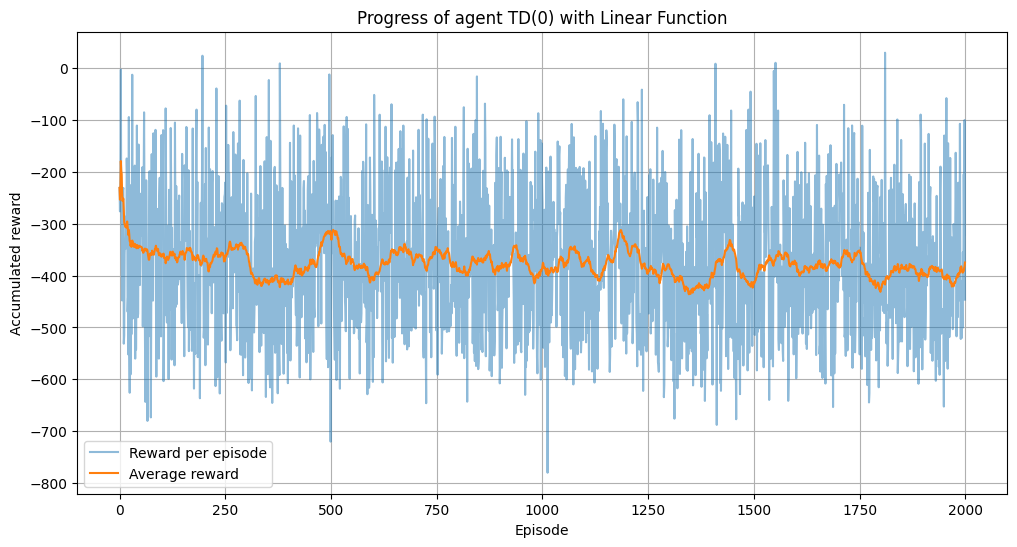

In [5]:
episode_rewards = np.load("outputs/episode_rewards_linear_function.npy")
avg_rewards = np.load("outputs/avg_rewards_linear_function.npy")
title = "Progress of agent TD(0) with Linear Function"

plot_rewards(episode_rewards, avg_rewards, title)

# Neuronal Network Approximator

In [6]:
class ValueNetwork(nn.Module):
    def __init__(self, feature_size):
        super().__init__()
        self.fc1 = nn.Linear(feature_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)

        self.af = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.af(x)

        x = self.fc2(x)
        x = self.af(x)

        x = self.fc3(x)
        return x

class NeuronalNetworkTD0Agent:
    def __init__(self, env, alpha, gamma):
        self.env = env
        self.gamma = gamma
        self.feature_size = env.observation_space.shape[0]

        self.model = ValueNetwork(self.feature_size).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=alpha)
        self.loss_fn = nn.MSELoss()

    def policy(self):
        return self.env.action_space.sample()

    def learn(self, features, reward, next_features, done):
        self.model.train()

        features = torch.tensor(features, dtype=torch.float32).to(device)
        reward = torch.tensor(reward, dtype=torch.float32).to(device)
        next_features = torch.tensor(next_features, dtype=torch.float32).to(device)
        done = torch.tensor(done, dtype=torch.float32).to(device)

        v_s = self.model(features)
        with torch.no_grad():
            if done:
                v_s_next = torch.tensor([0.0], device=device)
            else:
                v_s_next = self.model(next_features)

        td_target = reward + self.gamma * v_s_next
        loss = self.loss_fn(v_s, td_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def generate_episode(self):
        sum_rewards = 0
        state, _ = self.env.reset()
        features = preprocess(state)
        done = False

        while not done:
            action = self.policy()
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            next_features = preprocess(next_state)
            done = terminated or truncated

            self.learn(features, reward, next_features, done)

            state = next_state
            features = next_features
            sum_rewards += reward
        return sum_rewards

    def save(self, filename):
        torch.save(self.model.state_dict(), filename)

agent = NeuronalNetworkTD0Agent(env, alpha, gamma)
episode_rewards = []
avg_rewards = []

for episode in range(num_episodes):
    sum_rewards = agent.generate_episode()
    episode_rewards.append(sum_rewards)
    if episode >= rolling_window:
        avg_reward = np.mean(episode_rewards[episode-rolling_window:episode])
        avg_rewards.append(avg_reward)
    else:
        avg_reward = np.mean(episode_rewards[:episode+1])
        avg_rewards.append(avg_reward)
    print(f"Episode: {episode}, Sum Rewards: {sum_rewards}, Avg Rewards: {avg_reward}")

agent.save(f"outputs/weights_neuronal_network.pt")
np.save("outputs/episode_rewards_neuronal_network.npy", episode_rewards)
np.save("outputs/avg_rewards_neuronal_network.npy", avg_rewards)
env.close()


Episode: 0, Sum Rewards: -279.2143245631543, Avg Rewards: -279.2143245631543
Episode: 1, Sum Rewards: -97.58270712700198, Avg Rewards: -188.39851584507815
Episode: 2, Sum Rewards: -580.6464179107318, Avg Rewards: -319.14781653362934
Episode: 3, Sum Rewards: -350.91080160372576, Avg Rewards: -327.08856280115344
Episode: 4, Sum Rewards: -332.5625601328052, Avg Rewards: -328.1833622674838
Episode: 5, Sum Rewards: -141.7094992708253, Avg Rewards: -297.104385101374
Episode: 6, Sum Rewards: -366.1504864517883, Avg Rewards: -306.9681138657189
Episode: 7, Sum Rewards: -107.34024245045244, Avg Rewards: -282.01462993881063
Episode: 8, Sum Rewards: -176.20548072643504, Avg Rewards: -270.25805780410224
Episode: 9, Sum Rewards: -483.08236092695347, Avg Rewards: -291.54048811638734
Episode: 10, Sum Rewards: -118.35049524846238, Avg Rewards: -275.7959433102123
Episode: 11, Sum Rewards: -228.08158217657896, Avg Rewards: -271.8197465490762
Episode: 12, Sum Rewards: -279.3223574494426, Avg Rewards: -272

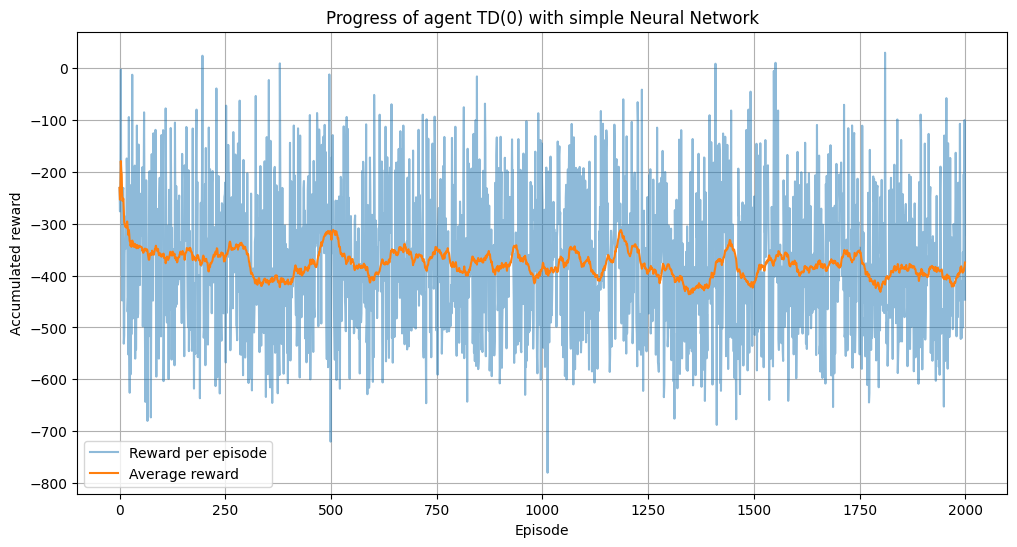

In [7]:
episode_rewards = np.load("outputs/episode_rewards_neuronal_network.npy")
avg_rewards = np.load("outputs/avg_rewards_neuronal_network.npy")
title = "Progress of agent TD(0) with simple Neural Network"

plot_rewards(episode_rewards, avg_rewards, title)

# Linear Function Approximator with Replay Buffer

In [8]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.pointer = 0
        self.size = 0
        self.capacity = capacity
        self.state_size = env.observation_space.shape[0]
        self.next_state_size = env.observation_space.shape[0]
        self.reward_size = 1
        self.done_size = 1
        self.total_transition_size = self.state_size + self.reward_size + self.next_state_size + self.done_size
        self.buffer = np.zeros((self.capacity, self.total_transition_size), dtype=np.float32)

    def sample(self, batch_size):
        if self.size < batch_size: 
            raise ValueError("Replay buffer is smaller than batch size.")
        
        random_indices = np.random.choice(self.size, batch_size, replace=False)
        features = self.buffer[random_indices, :self.state_size]
        rewards = self.buffer[random_indices, self.state_size:self.state_size+self.reward_size]
        next_features = self.buffer[random_indices, self.state_size+self.reward_size:self.state_size+self.reward_size+self.next_state_size]
        dones = self.buffer[random_indices, -self.done_size:]
        return features, rewards.squeeze(-1), next_features, dones.squeeze(-1)
    
    def write(self, features, reward, next_features, done):
        transition = np.concatenate((features, [float(reward)], next_features, [float(done)]))
        self.buffer[self.pointer] = transition
        self.pointer = (self.pointer + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)
    
class LinearFunctionTD0RBAgent(object):
    def __init__(self, env, alpha, gamma, replay_buffer, batch_size, updates_per_step):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.feature_size = env.observation_space.shape[0]
        self.replay_buffer = replay_buffer
        self.batch_size = batch_size
        self.updates_per_step = updates_per_step
        self.theta = np.zeros(self.feature_size)

    def policy(self):
        return self.env.action_space.sample()

    def learn(self, features, rewards, next_features, dones):
        v_s = np.dot(features, self.theta)
        v_s_next = np.dot(next_features, self.theta)
        v_s_next[dones == 1.0] = 0

        td_target = rewards + self.gamma * v_s_next
        td_error = td_target - v_s
        self.theta += self.alpha * np.dot(td_error, features)
    
    def get_minibatch(self):
        if self.replay_buffer.size >= self.batch_size:
            features, rewards, next_features, dones = self.replay_buffer.sample(self.batch_size)
            self.learn(features, rewards, next_features, dones)

    def generate_episode(self):
        sum_rewards = 0
        state, _ = self.env.reset(seed=seed)
        features = preprocess(state)
        done = False

        while not done:
            action = self.policy()
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            next_features = preprocess(next_state)
            done = terminated or truncated

            self.replay_buffer.write(features, reward, next_features, done)
            for _ in range(self.updates_per_step):
                self.get_minibatch()

            state = next_state
            features = next_features
            sum_rewards += reward

        return sum_rewards

replay_buffer = ReplayBuffer(buffer_capacity)
agent = LinearFunctionTD0RBAgent(env, alpha, gamma, replay_buffer, batch_size, updates_per_step)
episode_rewards = []
avg_rewards = []

for episode in range(num_episodes):
    sum_rewards = agent.generate_episode()
    episode_rewards.append(sum_rewards)
    if episode >= rolling_window:
        avg_reward = np.mean(episode_rewards[episode-rolling_window:episode])
        avg_rewards.append(avg_reward)
    else:
        avg_reward = np.mean(episode_rewards[:episode+1])
        avg_rewards.append(avg_reward)
    print(f"Episode: {episode}, Sum Rewards: {sum_rewards}, Avg Rewards: {avg_reward}")

np.save("outputs/theta_linear_function_replay_buffer.npy", agent.theta)
np.save("outputs/episode_rewards_linear_function_replay_buffer.npy", episode_rewards)
np.save("outputs/avg_rewards_linear_function_replay_buffer.npy", avg_rewards)
env.close()

Episode: 0, Sum Rewards: -329.63366068023777, Avg Rewards: -329.63366068023777
Episode: 1, Sum Rewards: -505.95309290066325, Avg Rewards: -417.7933767904505
Episode: 2, Sum Rewards: -206.1095066984833, Avg Rewards: -347.23208675979475
Episode: 3, Sum Rewards: -434.06836925016717, Avg Rewards: -368.9411573823878
Episode: 4, Sum Rewards: -363.3941652062851, Avg Rewards: -367.83175894716726
Episode: 5, Sum Rewards: -576.6566003003767, Avg Rewards: -402.6358991727022
Episode: 6, Sum Rewards: -434.34391944464727, Avg Rewards: -407.1656163544086
Episode: 7, Sum Rewards: -475.265432518325, Avg Rewards: -415.67809337489814
Episode: 8, Sum Rewards: -441.1648429834366, Avg Rewards: -418.50995444251356
Episode: 9, Sum Rewards: -322.75898712576833, Avg Rewards: -408.934857710839
Episode: 10, Sum Rewards: -315.2679703675211, Avg Rewards: -400.41968613417373
Episode: 11, Sum Rewards: -56.330192712955096, Avg Rewards: -371.7455616824055
Episode: 12, Sum Rewards: -538.4989389579446, Avg Rewards: -384.

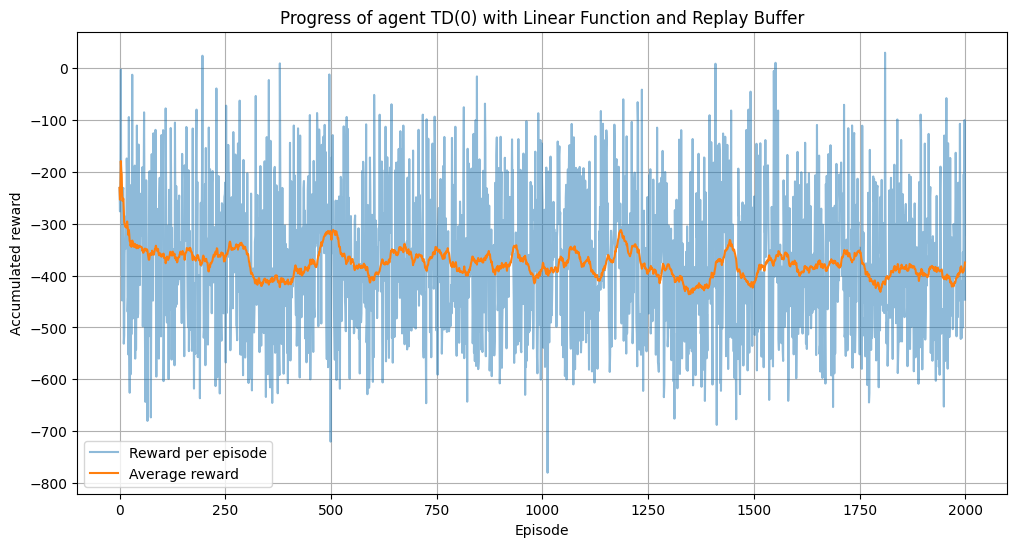

In [9]:
episode_rewards = np.load("outputs/episode_rewards_linear_function_replay_buffer.npy")
avg_rewards = np.load("outputs/avg_rewards_linear_function_replay_buffer.npy")
title = "Progress of agent TD(0) with Linear Function and Replay Buffer"

plot_rewards(episode_rewards, avg_rewards, title)

# Neuronal Network Approximator with Replay Buffer

In [10]:
class ValueNetwork(nn.Module):
    def __init__(self, feature_size):
        super().__init__()
        self.fc1 = nn.Linear(feature_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)
        
        self.bn = nn.BatchNorm1d(256)

        self.af = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn(x)
        x = self.af(x)

        x = self.fc2(x)
        x = self.af(x)

        x = self.fc3(x)
        return x

class ReplayBuffer:
    def __init__(self, capacity):
        self.pointer = 0
        self.size = 0
        self.capacity = capacity
        self.state_size = env.observation_space.shape[0]
        self.next_state_size = env.observation_space.shape[0]
        self.reward_size = 1
        self.done_size = 1
        self.total_transition_size = self.state_size + self.reward_size + self.next_state_size + self.done_size
        self.buffer = np.zeros((self.capacity, self.total_transition_size), dtype=np.float32)

    def sample(self, batch_size):
        if self.size < batch_size: 
            raise ValueError("Replay buffer is smaller than batch size.")
        
        random_indices = np.random.choice(self.size, batch_size, replace=False)
        features = self.buffer[random_indices, :self.state_size]
        rewards = self.buffer[random_indices, self.state_size:self.state_size+self.reward_size]
        next_features = self.buffer[random_indices, self.state_size+self.reward_size:self.state_size+self.reward_size+self.next_state_size]
        dones = self.buffer[random_indices, -self.done_size:]
        return features, rewards.squeeze(-1), next_features, dones.squeeze(-1)
    
    def write(self, features, reward, next_features, done):
        transition = np.concatenate((features, [float(reward)], next_features, [float(done)]))
        self.buffer[self.pointer] = transition
        self.pointer = (self.pointer + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)
        
class NeuronalNetworkRBTD0Agent:
    def __init__(self, env, alpha, gamma, replay_buffer, batch_size, updates_per_step):
        self.env = env
        self.gamma = gamma
        self.feature_size = env.observation_space.shape[0]
        self.replay_buffer = replay_buffer
        self.batch_size = batch_size
        self.updates_per_step = updates_per_step

        self.model = ValueNetwork(self.feature_size).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=alpha)
        self.loss_fn = nn.MSELoss()

    def policy(self):
        return self.env.action_space.sample()

    def learn(self, features, rewards, next_features, dones):
        self.model.train()

        features = torch.tensor(features, dtype=torch.float32).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
        next_features = torch.tensor(next_features, dtype=torch.float32).to(device)
        dones = torch.tensor(dones, dtype=torch.float32).to(device)

        v_s = self.model(features).squeeze()
        with torch.no_grad():
            v_s_next = self.model(next_features).squeeze()
            v_s_next[dones == 1.0] = 0

        td_target = rewards + self.gamma * v_s_next
        loss = self.loss_fn(v_s, td_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def get_minibatch(self):
        if self.replay_buffer.size >= self.batch_size:
            features, rewards, next_features, dones = self.replay_buffer.sample(self.batch_size)
            self.learn(features, rewards, next_features, dones)

    def generate_episode(self):
        sum_rewards = 0
        state, _ = self.env.reset(seed=seed)
        features = preprocess(state)
        done = False

        while not done:
            action = self.policy()
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            next_features = preprocess(next_state)
            done = terminated or truncated

            self.replay_buffer.write(features, reward, next_features, done)
            for _ in range(self.updates_per_step):
                self.get_minibatch()

            state = next_state
            features = next_features
            sum_rewards += reward
        return sum_rewards

    def save(self, filename):
        torch.save(self.model.state_dict(), filename)

replay_buffer = ReplayBuffer(buffer_capacity)
agent = NeuronalNetworkRBTD0Agent(env, alpha, gamma, replay_buffer, batch_size, updates_per_step)
episode_rewards = []
avg_rewards = []

for episode in range(num_episodes):
    sum_rewards = agent.generate_episode()
    episode_rewards.append(sum_rewards)
    if episode >= rolling_window:
        avg_reward = np.mean(episode_rewards[episode-rolling_window:episode])
        avg_rewards.append(avg_reward)
    else:
        avg_reward = np.mean(episode_rewards[:episode+1])
        avg_rewards.append(avg_reward)
    print(f"Episode: {episode}, Sum Rewards: {sum_rewards}, Avg Rewards: {avg_reward}")

agent.save(f"outputs/weights_neuronal_network_replay_buffer.pt")
np.save("outputs/episode_rewards_neuronal_network_replay_buffer.npy", episode_rewards)
np.save("outputs/avg_rewards_neuronal_network_replay_buffer.npy", avg_rewards)
env.close()

Episode: 0, Sum Rewards: -577.410779140692, Avg Rewards: -577.410779140692
Episode: 1, Sum Rewards: -550.1793551091813, Avg Rewards: -563.7950671249366
Episode: 2, Sum Rewards: -344.30695742030525, Avg Rewards: -490.6323638900595
Episode: 3, Sum Rewards: -509.02749676905574, Avg Rewards: -495.23114710980855
Episode: 4, Sum Rewards: -467.6681764294416, Avg Rewards: -489.71855297373514
Episode: 5, Sum Rewards: -573.1222339950102, Avg Rewards: -503.61916647728094
Episode: 6, Sum Rewards: -312.97933266194264, Avg Rewards: -476.38490450366123
Episode: 7, Sum Rewards: -198.43083451684697, Avg Rewards: -441.64064575530944
Episode: 8, Sum Rewards: -129.71076641792675, Avg Rewards: -406.981770273378
Episode: 9, Sum Rewards: -607.2526064776525, Avg Rewards: -427.00885389380545
Episode: 10, Sum Rewards: -445.48941325781817, Avg Rewards: -428.68890474507936
Episode: 11, Sum Rewards: -548.2538665355521, Avg Rewards: -438.6526515609521
Episode: 12, Sum Rewards: -66.51507541022573, Avg Rewards: -410.

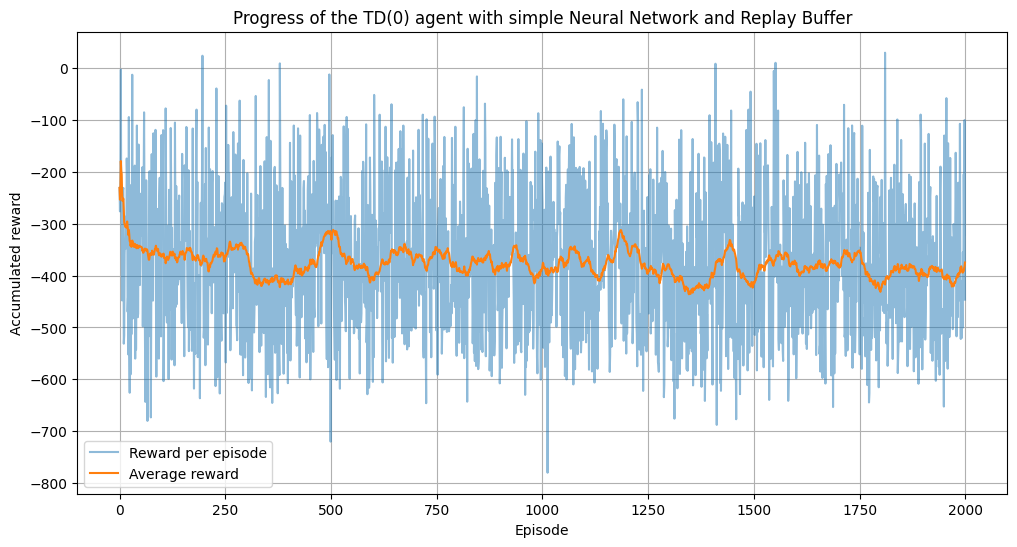

In [11]:
episode_rewards = np.load("outputs/episode_rewards_neuronal_network_replay_buffer.npy")
avg_rewards = np.load("outputs/avg_rewards_neuronal_network_replay_buffer.npy")
title = "Progress of the TD(0) agent with simple Neural Network and Replay Buffer"

plot_rewards(episode_rewards, avg_rewards, title)